In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## Data Preparation

In [2]:
df = pd.read_csv(r"D:\Kuliah\TUGAS\Semester 5\Machine Learning\W2-21 September 26\data\titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.shape

(891, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Handling missing value

In [7]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df.drop(columns=['Cabin'], inplace=True)

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## EDA

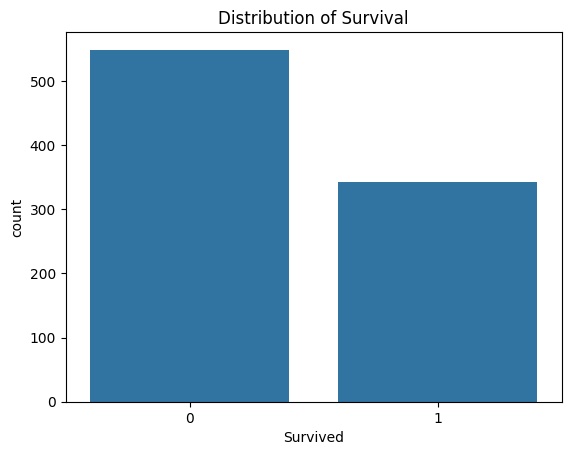

In [8]:
sns.countplot(data=df, x="Survived")
plt.title("Distribution of Survival")
plt.show()

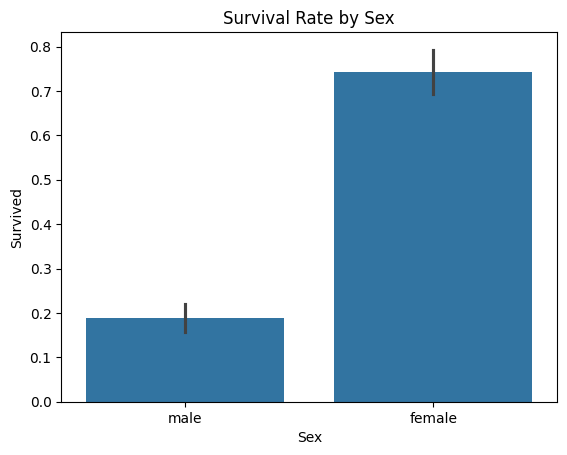

In [9]:
sns.barplot(data=df, x="Sex", y="Survived")
plt.title("Survival Rate by Sex")
plt.show()

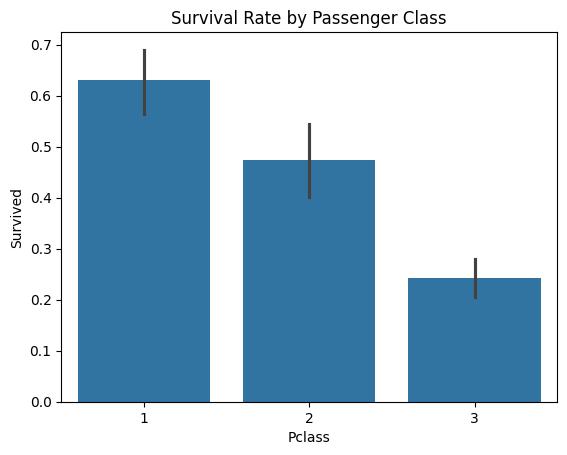

In [10]:
sns.barplot(data=df, x="Pclass", y="Survived")
plt.title("Survival Rate by Passenger Class")
plt.show()

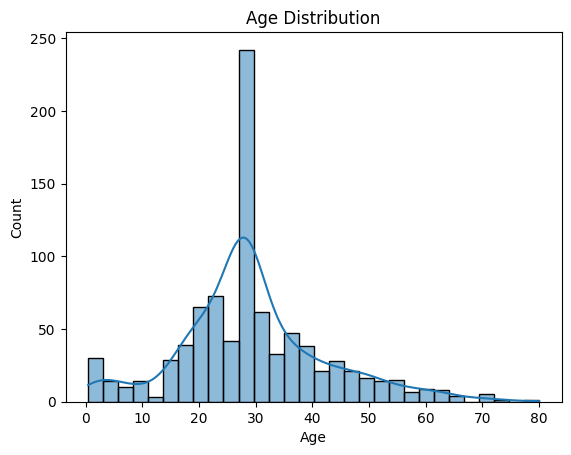

In [11]:
sns.histplot(data=df, x="Age", kde=True)
plt.title("Age Distribution")
plt.show()

## Feature Selection

In [ ]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

numeric_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

categorical_features = [
    "Sex",
    "Embarked"
]

In [ ]:
X = df[features]
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=123,
    stratify=y
)

## Scaling

In [15]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

## Modeling

In [16]:
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)

In [17]:
baseline_accuracy = accuracy_score(y_test, y_pred)
baseline_precision = precision_score(y_test, y_pred)
baseline_recall = recall_score(y_test, y_pred)
baseline_f1 = f1_score(y_test, y_pred)

print("Accuracy :", baseline_accuracy)
print("Precision:", baseline_precision)
print("Recall   :", baseline_recall)
print("F1 Score :", baseline_f1)

Accuracy : 0.7932960893854749
Precision: 0.7352941176470589
Recall   : 0.7246376811594203
F1 Score : 0.7299270072992701


## Feature Engineering

In [ ]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

FamilySize dibuat untuk merepresentasikan ukuran keluarga penumpang secara keseluruhan. Dua penumpang dengan nilai SibSp dan Parch yang berbeda dapat memiliki kondisi sosial yang berbeda. Fitur ini menggabungkan informasi keluarga menjadi satu variabel yang lebih mudah digunakan model.

In [19]:
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

Fitur IsAlone digunakan untuk menangkap kondisi apakah penumpang bepergian sendiri. Informasi ini bersifat lebih spesifik daripada FamilySize karena membedakan penumpang yang benar-benar tidak memiliki anggota keluarga lain dalam perjalanan.

In [20]:
df["LogFare"] = np.log1p(df["Fare"])

Transformasi log digunakan untuk mengurangi skewness pada variabel Fare. Dengan distribusi yang lebih terkompresi, perbedaan antara nilai tarif yang sangat besar dan nilai tarif yang lebih kecil tidak terlalu mendominasi model.

In [21]:
bins = [0, 12, 18, 35, 60, np.inf]

labels = [
    "Child",
    "Teenager",
    "YoungAdult",
    "Adult",
    "Senior"
]

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

AgeGroup dibuat dengan mengubah umur kontinu menjadi beberapa kelompok. Tujuannya adalah memungkinkan model menangkap kemungkinan adanya pola survival yang berbeda antar kelompok usia tanpa hanya bergantung pada hubungan linear antara Age dan target.

### Modeling

In [22]:
engineered_features = [
    "Pclass",
    "Sex",
    "Age",
    "AgeGroup",
    "SibSp",
    "Parch",
    "FamilySize",
    "IsAlone",
    "Fare",
    "LogFare",
    "Embarked"
]

numeric_features_fe = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "FamilySize",
    "IsAlone",
    "Fare",
    "LogFare"
]

categorical_features_fe = [
    "Sex",
    "AgeGroup",
    "Embarked"
]

In [23]:
numeric_pipeline_fe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline_fe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_fe = ColumnTransformer([
    ("num", numeric_pipeline_fe, numeric_features_fe),
    ("cat", categorical_pipeline_fe, categorical_features_fe)
])

In [25]:
X_fe = df[engineered_features]
y_fe = df["Survived"]

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe,
    y_fe,
    test_size=0.2,
    random_state=42,
    stratify=y_fe
)

In [26]:
fe_model = Pipeline([
    ("preprocessor", preprocessor_fe),
    ("model", LogisticRegression(max_iter=1000))
])

fe_model.fit(X_train_fe, y_train_fe)
y_pred_fe = fe_model.predict(X_test_fe)

In [27]:
accuracy_fe = accuracy_score(y_test_fe, y_pred_fe)
precision_fe = precision_score(y_test_fe, y_pred_fe)
recall_fe = recall_score(y_test_fe, y_pred_fe)
f1_fe = f1_score(y_test_fe, y_pred_fe)

print("Feature Engineering Model")
print("-------------------------")
print(f"Accuracy : {accuracy_fe:.4f}")
print(f"Precision: {precision_fe:.4f}")
print(f"Recall   : {recall_fe:.4f}")
print(f"F1 Score : {f1_fe:.4f}")

Feature Engineering Model
-------------------------
Accuracy : 0.8212
Precision: 0.8136
Recall   : 0.6957
F1 Score : 0.7500


## Compare

In [28]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Feature Engineering"
    ],
    "Accuracy": [
        baseline_accuracy,
        accuracy_fe
    ],
    "Precision": [
        baseline_precision,
        precision_fe
    ],
    "Recall": [
        baseline_recall,
        recall_fe
    ],
    "F1 Score": [
        baseline_f1,
        f1_fe
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline,0.793296,0.735294,0.724638,0.729927
1,Feature Engineering,0.821229,0.813559,0.695652,0.750000
